# Ellipsometry Analysis

We have started to receive ellipsometry data from Woollam on some of the LiF deposits created by Blue Ridge. Looking at the data by eye we have noticed a number of things and raised some questions.

 - They ran 4 LiF on Si and an LiF on glass (how? doesn't the machine only hold 4 wafers?)

 - The LiF on Si shows basically linear variation in thickness in each case but the variation is much larger than before (+/-5, +/-5, +/-3, +/-4 nm compared to +/-2 for orig.)

 - The oxide layer on the bare wafer this time is MUCH more variable than the first time (+/-7nm vs. +/-0.2nm).

 - The LiF on Si all show significant variations in LiF refractive index at about the same % level as thickness and anti-correlated. Are we seeing roughly constant optical path?? Does that mean roughly constant amount of Li??

 - Different wafers show different amounts of variation and some difference in angle.

 - For next run we want glass w/ 1mm and 2mm spacing in same orientation and 2mm at right angles to understand reproducibility.
 
We also had a Zoom call with Mathew Barber of Blue Ridge and Ron Synowicki of Woollam where we learned some additional information.

The machine has four 'planets' or 'platters' each of which can hold five 3" wafers. For the run in question they did 4 LiF coated etched Si wafers on one platter and a single 4" diameter LiF coated BK-7 wafer on a different platter. The etched wafers and the coated BK-7 wafer were subject to four different cleaning procedures described in a recent email from Matthew Barber

 - SN1: abrasive scrub w/ cloth, surfactant wash w/ sponge, trail-wipe w/  acetone, trail-wipe w/ methanol
 - SN2: trail-wipe w/ acetone, trail-wipe w/ methanol
 - SN3: trail-wipe w/ acetone, trail-wipe w/ methanol, dry-buff w/ kimwipe
 - SN4: abrasive scrub w/ sponge, surfactant wash w/ sponge, wet w/ distilled water, blow off w/ dry nitrogen
 - BK7 wafer: trail-wipe w/ acetone, trail-wipe w/ methanol
 
The extra variability of the SiO2 layer on the reference eteched wafer could well be explained by the etching process. Since the oxide thickness was treated as constant in the modeling for the wafers its variability could have been transferred to the thickness data. However, since the etching process is extremely unlikely to have treated each wafer the same it is not possible to use the oxide thickness to correct the LiF thicknesses.

Although the etched wafers have visibly hazy areas, especially round the edges, there was no difficulty in getting good ellipsometry data from them. Ron speculates that the haziness indicates the addition of some scattering to those portions of the surface which is not captured by the ellipsometer which records on the specularly reflected light.

The BY-7 sample was initially hard to fit the data until Ron added an intermediate layer of about 46 nm of LiF with a slightly modified refractive index. Matthew confirmed that they would expect the early part of the deposition to grow in patches and that only after that layer was complete would the rest of the layer grow more uniformly. However NONE of the Si wafers required such an extra layer.

I noticed that the refractive index values are anti-correlated with the height values across all four of the Si wafers. This raises the possibility that the optical path, and thus the actual number of Li atoms, may be much more uniform across the wafers than the thickness might suggest. Matthew confirmed that there might be variations of density, particularly across the plane of the deposit so that this is worth pursuing.

## Analysis

In order to start to take a look I will load some tools and then see about reading in the data set from wafer SN001.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

SN001 = np.loadtxt('Run11_25_SN001.txt', delimiter='\t', skiprows=5)
print(SN001[0,:])

[  1.      3.4   557.72    1.384   9.68 ]


Next I reformat the data into x, y, thickness, refractive index, and roughness columns.

In [3]:
x = SN001[:,0]
y = SN001[:,1]
t = SN001[:,2]
n = SN001[:,3]
rf = SN001[:,4]

and then I should be able to plot a map of the thickness data.

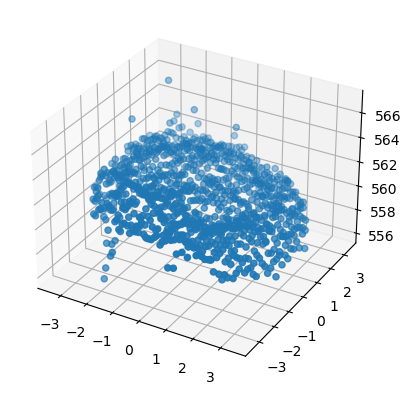

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
#surf = ax.plot_surface(x, y, t, cmap="coolwarm", linewidth=0, antialiased=False)
surf = ax.scatter(x, y, t)

So, apart from some scatterd points, especially near the edges, this looks like a tilted plane with about 4% variation across one axis. Let's look at the refractive index.

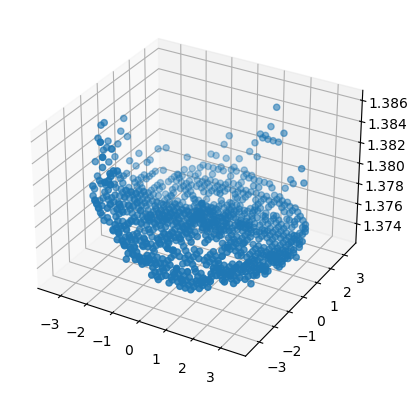

In [7]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.scatter(x, y, n)

Hard to tell. And if we plot the product of t and n (suitably scaled)?

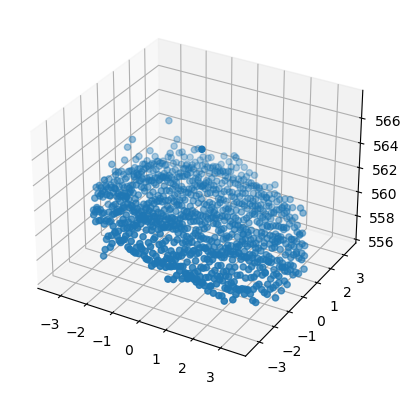

In [9]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.scatter(x, y, t*n/1.38)

It is maybe a little less scattered but still shows about the same slope.

## Slope Removal

The obvious first step is to remove the clear slope. For that we need to come up with an equation for a rotated slanted plane. Let's start by constructing a unit vector that is oriented at and angle $\theta$ to the x-axis. It has the form
$\vec{u} = \cos(\theta)\vec{i} + \sin(\theta)\vec{j}$
and then we know that the right-handed unit vector perpendicular to this is
$\vec{v} = -\sin(\theta)\vec{i} + \cos(\theta)\vec{j}$
so that
$\vec{u} \cdot{} \vec{v} = -\sin(\theta)\cos(\theta) + \cos(\theta)\sin(\theta) = 0$
in this system we then form a plane sloped in the u-direction and flat in v as
$$\zeta(\xi, \eta) = z_0 + m \times{} \xi$$
where $\xi$ and $\eta$ are the coordinates in the rotated frame. For this we need a rotational transformation between $x, y$ and $\xi, \eta$

![Rotated coordinate system](Rotation.png)

We can do this with a little algebraic geometry. We seek to represent the same point in the two coordinate systems so that
$$\xi\vec{u} + \eta\vec{v} = x\vec{i} + y\vec{j}$$
Since we want to express $\xi$ and $\eta$ in terms of $x$ nd $y$ we start by dotting with $\vec{u}$ to pull out the $\xi$ term.
$$\xi\vec{u}\cdot{}\vec{u} + \eta\vec{v}\cdot{}\vec{u} = \xi = x \vec{i}\cdot{}\vec{u} + y \vec{j}\cdot{}\vec{u} = x\cos(\theta) + y\cos(\pi/2-\theta) = x\cos(\theta) + y\sin(\theta)$$
since $\vec{u}$ is perpendicular to $\vec{v}$.

Then we can find $\eta$ by dotting with $\vec(v)$ to get
$$\xi\vec{u}\cdot{}\vec{v} + \eta\vec{v}\cdot{}\vec{v} = \eta = x \vec{i}\cdot{}\vec{v} + y \vec{j}\cdot{}\vec{v} = x\cos(\pi/2+\theta) + y\cos(\theta) = -x\sin(\theta) + y\cos(\theta)$$

So we have
$$\xi = x\cos(\theta) + y\sin(\theta)$$
and
$$\eta = -x\sin(\theta) + y\cos(\theta)$$
so that our equation for the fit height becomes
$$\zeta(x, y) = z_0 + m \times{} \left( x\cos(\theta) + y\sin(\theta) \right)$$

There are a number of places that that could have introduced an error so let's check. We'll set $\theta = \pi/6a$ so that $\cos(\theta) = 0.5$ and $\sin(\theta) = \sqrt{3}/2$ and see if we get a plane where downhill is 30° above the x axis.

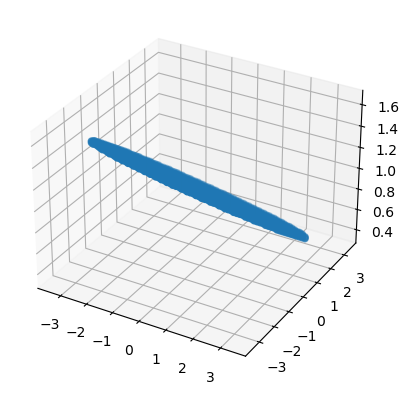

In [11]:
sin60 = np.sqrt(3.0)
cos60 = 0.5
zeta = 1 - 0.1 * (x*cos60 + y*sin60)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.scatter(x, y, zeta)

Trying again with -10°

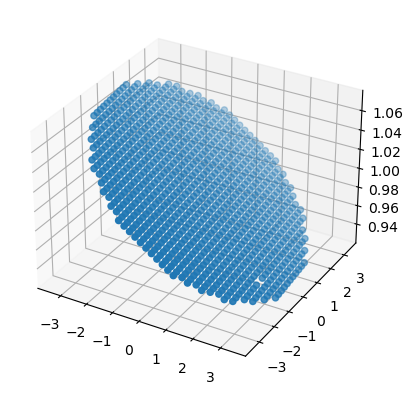

In [13]:
sinm10 = -np.sin(np.pi/18)
cosm10 = np.cos(np.pi/18)
zeta1 = 1 - 0.02 * (x*cosm10 + y*sinm10)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.scatter(x, y, zeta1)

Let's try a different kind of plot. A contour plot or a colored 2-D scatter plot might work.

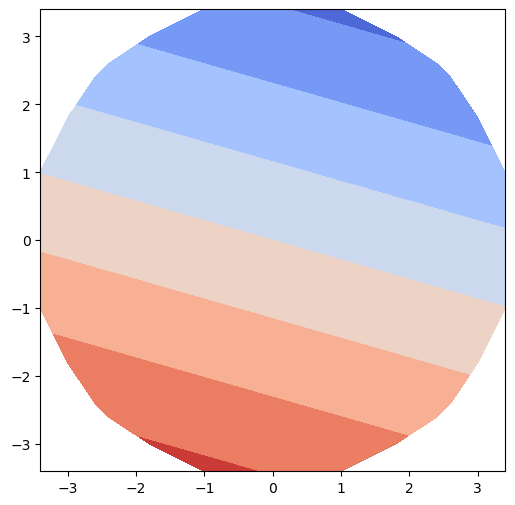

In [27]:
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig, ax = plt.subplots(figsize=(6,6))
s60 = ax.tricontourf(x, y, zeta, cmap='coolwarm')

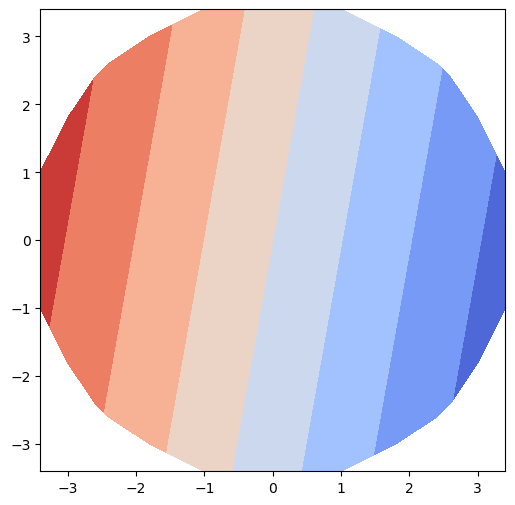

In [28]:
fig, ax = plt.subplots(figsize=(6,6))
s60 = ax.tricontourf(x, y, zeta1, cmap='coolwarm')

Well, accounting for the distortion caused by the non-square axis box those make pretty good sense. What if we plot our data the same way?

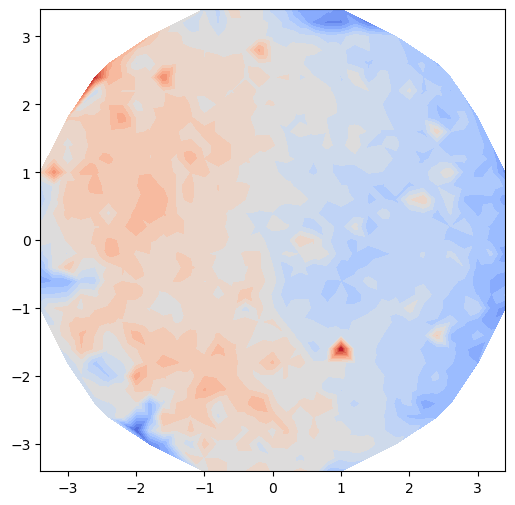

In [26]:
fig, ax = plt.subplots(figsize=(6,6))
s60 = ax.tricontourf(x, y, t, levels=21, 
                     cmap='coolwarm')

That is pretty much axis oriented with low edges. Here is how Taylor would have plotted to show the actual data points and then a method to match the way Ron did it.

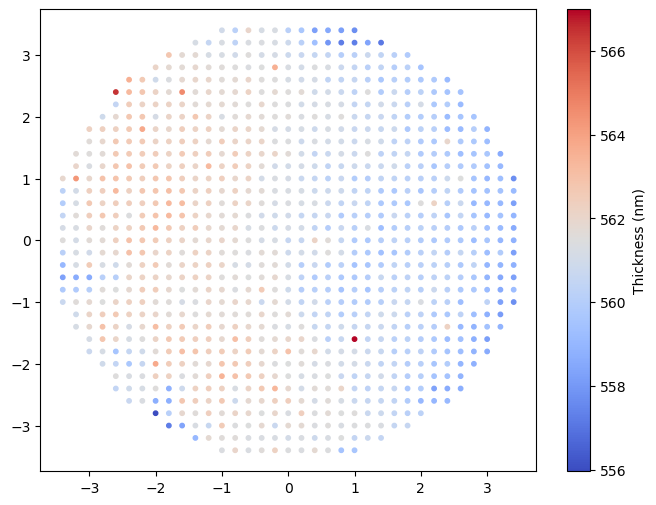

In [38]:
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig, ax = plt.subplots(figsize=(8,6))
c = ax.scatter(x, y, c=t, cmap='coolwarm', s=10)
plt.colorbar(c, label='Thickness (nm)')

Text(0, 0.5, 'Y (cm)')

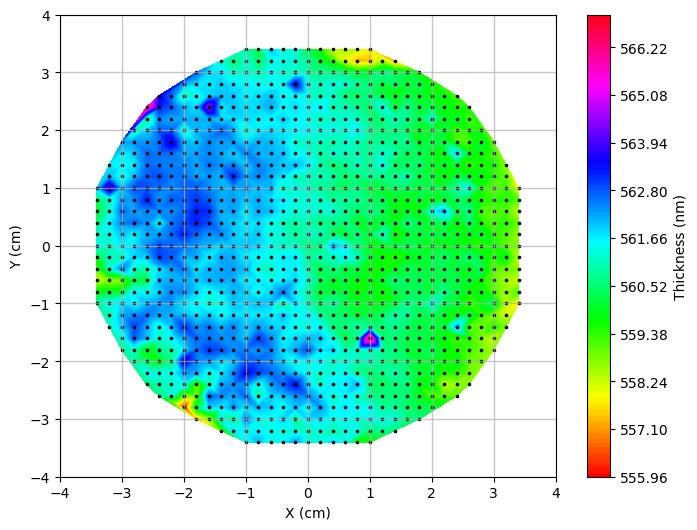

In [51]:
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig, ax = plt.subplots(figsize=(8,6))
c = ax.tricontourf(x, y, t, levels=201, cmap='hsv')
ax.scatter(x, y, c='k', marker='.', s=10)
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')

That looks really good now. Let's do it again with the optical depth.

Text(0.5, 1.0, 'Optical path length for LiF on SN001')

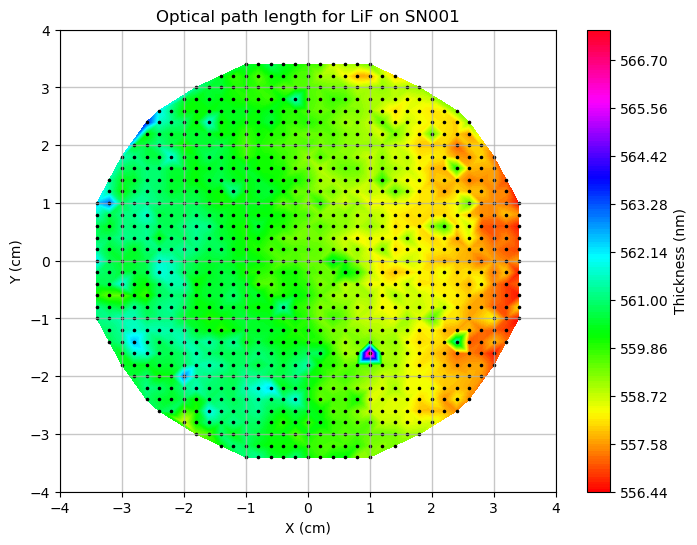

In [52]:
fig, ax = plt.subplots(figsize=(8,6))
c = ax.tricontourf(x, y, t*n/1.38, levels=201, cmap='hsv')
ax.scatter(x, y, c='k', marker='.', s=10)
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Optical path length for LiF on SN001')

Oh, interesting. It mostly just shifts the overall level slightly.

OK, so it appears that we could follow Taylor and build some standardized plotting functions. But I want to go beyond Taylor's collection of functions and group a given data set into an object that knows how to plot itself in various ways. This will grow to support fitting as well.

Note that I am not biulding robust error checks into this as I expect to be the only user and am happy to have the code raise a standard exception if I did something wrong.

In [90]:
from scipy import optimize

class DepositData:
    def __init__(self, x, y, z, n):
        self.name = None
        self.xdata = x
        self.ydata = y
        self.zdata = z
        self.ndata = n
        self.avg_thickness = np.average(self.zdata)
    
    def set_name(self, new_name):
        self.name = new_name
    
    def Ron_plot_on(self, ax):
        c = ax.tricontourf(self.xdata, self.ydata, self.zdata, levels=201, cmap='hsv')
        ax.scatter(self.xdata, self.ydata, c='k', marker='.', s=10)
        plt.colorbar(c, label='Thickness (nm)')
        plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.xlabel('X (cm)')
        plt.ylabel('Y (cm)')
        plt.title(f'LiF Thickness for {self.name}')

    def Ron_plot(self):
        fig, ax = plt.subplots(figsize=(8,6))
        self.Ron_plot_on(ax)
    
    # Class factory function to build a DepositData from a file
    def from_file(filename, data_name = None):
        arr = np.loadtxt(filename, delimiter='\t', skiprows=5)
        dd = DepositData(arr[:, 0], arr[:, 1], arr[:, 2], arr[:, 3]) 
        if data_name is not None:
            dd.set_name(data_name)
        return dd
    
    # Fit to some functional form
    # The fitting function should have the signature
    # fit_func(params, arg) where <params> will be the current
    # values of the fitting parameters and <arg> a tuple containing
    # the class. The function should return a single float value to minimize.
    # The p0 argument should hold the initial values of the parameters.
    def fit_to(self, fit_func, p0):
        return optimize.minimize(fit_func, p0, args=(self, ), method='BFGS', options={'maxiter': 5000})
            

So to use that we need a fitting function. It needs to build fit values from the parameters and then construct an error metric, normally the sum of the squared residuals, to return to the minimizer. Let's try for our angled plane. It has only three parameters; the central height, the angle, and slope.

In [69]:
# parameter definitions
# p[0]: z0
# p[1]: theta in radians
# p[2]: the slope
def angled_plane(x, y, p):
    stheta = np.sin(p[1])
    ctheta = np.cos(p[1])
    zplane = p[0] - p[2] * (x*ctheta + y*stheta)
    return zplane

and a quick test

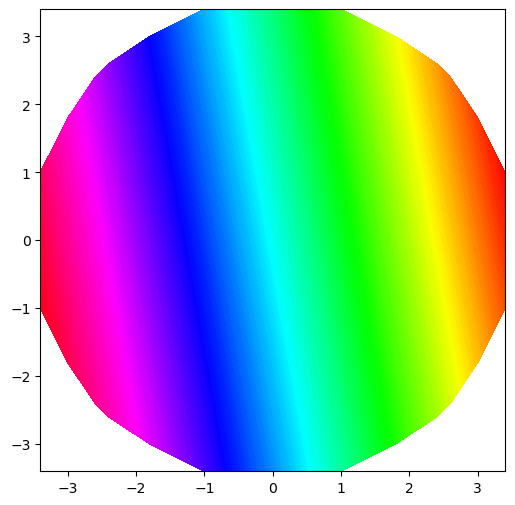

In [71]:
p10 = [t[494], np.pi/18, 1.0]
zf10 = angled_plane(x, y, p10)
fig, ax = plt.subplots(figsize=(6,6))
ax.tricontourf(x, y, zf10,  levels=201, cmap='hsv')

So that works fine. From that we construct a fitting function that computes the residuals. It would probably be good to add the residuals to the data class for later plotting and study. To test this we need to actually build a class from our data.

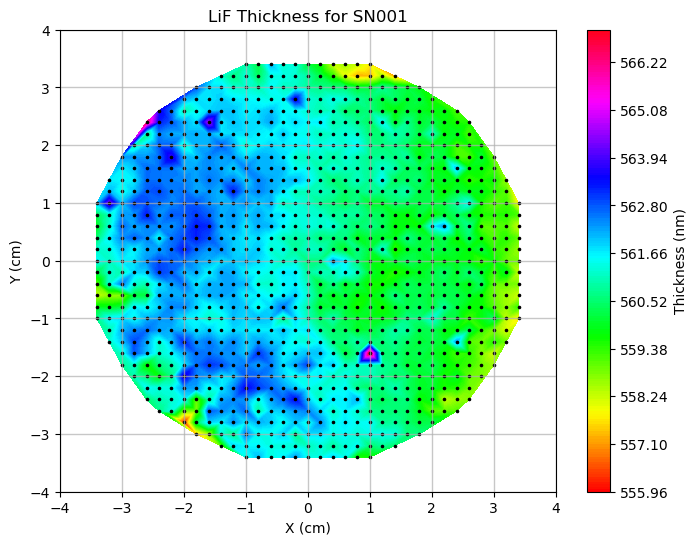

In [112]:
Si001 = DepositData(x, y, t, n)
Si001.set_name('SN001')
Si001.Ron_plot()

In [92]:
def planar_fit(params, args):
    data = args
    zfit = angled_plane(data.xdata, data.ydata, params)
    resids = data.zdata - zfit
    res_sq = resids * resids
    return np.sum(res_sq)

and a quick test

In [94]:
planar_fit(p10, Si001)

1932.5365063757765

In [96]:
res = Si001.fit_to(planar_fit, p10)

In [97]:
print(res)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 773.4474554100075
        x: [ 5.610e+02  2.665e-03  4.557e-01]
      nit: 14
      jac: [ 0.000e+00  7.629e-06  3.815e-05]
 hess_inv: [[ 3.468e-04 -2.694e-05  1.180e-04]
            [-2.694e-05  6.668e-05 -7.108e-05]
            [ 1.180e-04 -7.108e-05  2.047e-04]]
     nfev: 96
     njev: 24


In [109]:
zf = angled_plane(Si001.xdata, Si001.ydata, res.x)
print(zf.shape)

(988,)


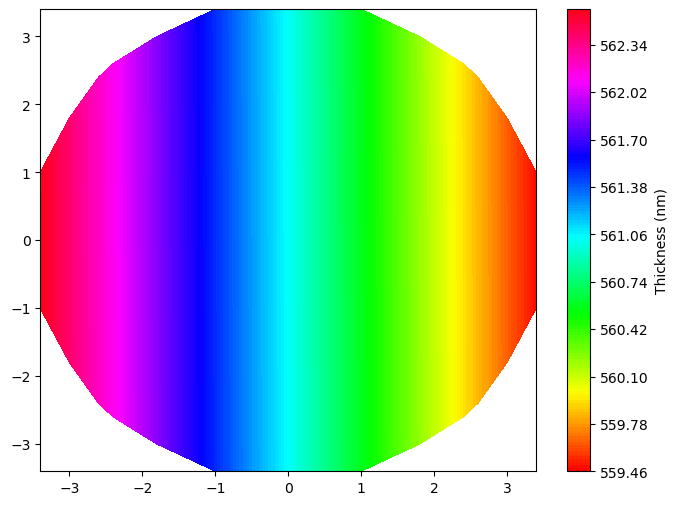

In [110]:
fig, ax = plt.subplots(figsize=(8,6))
p10 = ax.tricontourf(x, y, zf,  levels=201, cmap='hsv')
plt.colorbar(p10, label='Thickness (nm)')

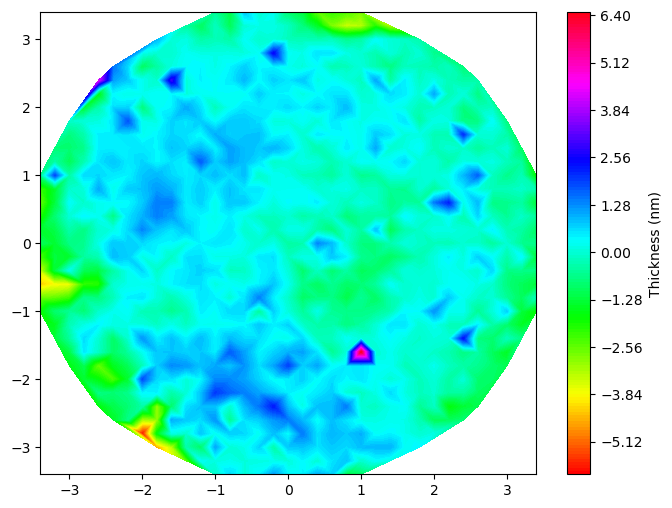

In [113]:
resids = Si001.zdata - zf
fig, ax = plt.subplots(figsize=(8,6))
p11 = ax.tricontourf(x, y, resids,  levels=201, cmap='hsv')
plt.colorbar(p11, label='Thickness (nm)')

Well, that seems to have worked rather well. We are left with a sort of donut shaped error pattern centered slightly to the right of the actual deposit center. Apart from a few clear bumps this is down at the $\pm1\,nm$ level. This is actually roughly the same magnitude as the angled plane, however.

Let's look at another deposit.

### SN002

Start by looking at it.

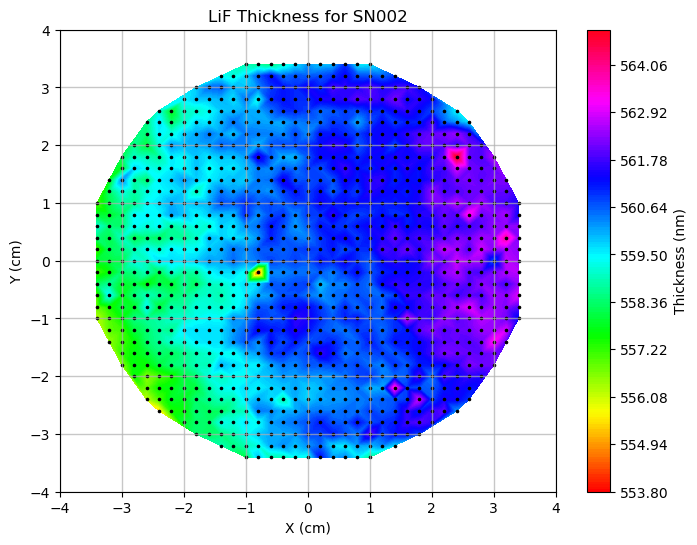

In [115]:
SN002 = DepositData.from_file('Run11_25_SN002.txt', data_name='SN002')
SN002.Ron_plot()

Again, the slope is pretty much at angle 0 but this time it is high on the right instead of the left. Let's try a fit.

In [117]:
p02 = [SN002.zdata[494], 0.0, -1.0]
res2 = SN002.fit_to(planar_fit, p02)

In [120]:
print(res2)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 394.95500917233045
        x: [ 5.604e+02  1.971e-01 -6.709e-01]
      nit: 8
      jac: [ 0.000e+00 -3.433e-05  1.717e-04]
 hess_inv: [[ 2.961e-03 -7.956e-03 -2.717e-03]
            [-7.956e-03  2.604e-02  8.854e-03]
            [-2.717e-03  8.854e-03  3.012e-03]]
     nfev: 205
     njev: 48


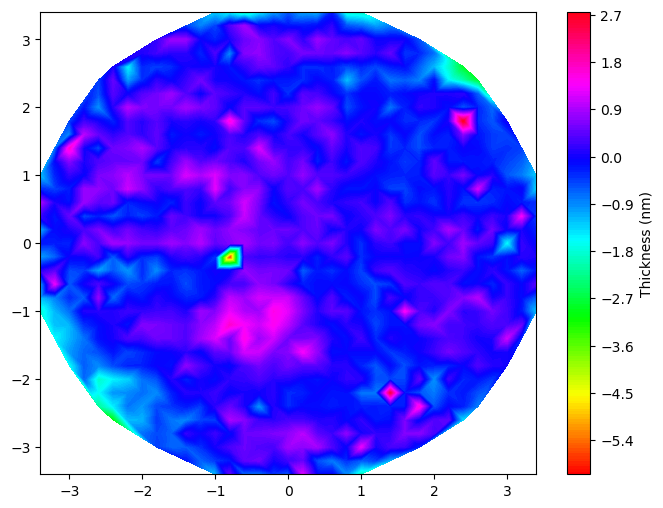

In [119]:
zf2 = angled_plane(SN002.xdata, SN002.ydata, res2.x)
resids2 = SN002.zdata - zf2
fig, ax = plt.subplots(figsize=(8,6))
p12 = ax.tricontourf(SN002.xdata, SN002.ydata, resids2,  levels=201, cmap='hsv')
plt.colorbar(p12, label='Thickness (nm)')

Again an excellent fit in that it has removed the obvious shape. Again, however, it had not reduced the overall range much.

I know what we need. We need a histogram of the heights. I am going to use an example straight from pyplot.

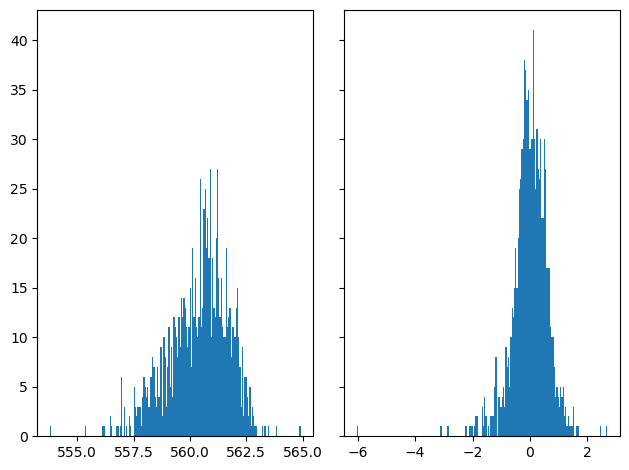

In [121]:
fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(SN002.zdata, bins=201)
axs[1].hist(resids2, bins=201)

plt.show()

Well, that is interesting. The original distribution is clearly non-normal and apart from outliers, extends from 557.5 to 562.5+, a range of 5+ nm. With the slope removed the ditribution has sharpened dramatically and it has become a lot more normal. Again ignoring outliers, the full width is down to something under 4 nm.

Let's try a 3-D plot of the residuals to see if more shape emerges.

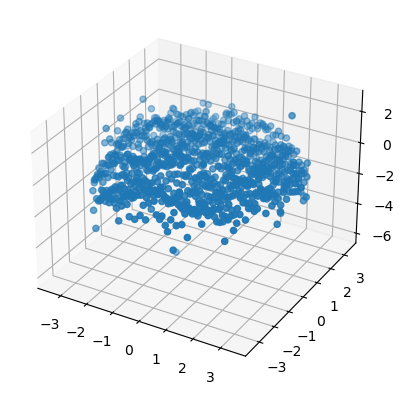

In [122]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.scatter(SN002.xdata, SN002.ydata, resids2)

It is a little hard to see from this angle but there are suggestions of a slight curvature. I am going to run the same thing again in Spyder so I can rotate the plot. That allows me to see it like this,

![Flat residuals of SN002](SN002Resids3D.png)

showing that it is now basically flat with noise across the center and dips slightly round the edges. This is beautiful!

NOTE that the work to generate this has resulted in a newer, expanded, version of the DepositData class that now lives in its own Python module file DepositData.py.

### SN003

Let's use the new tools on SN003.

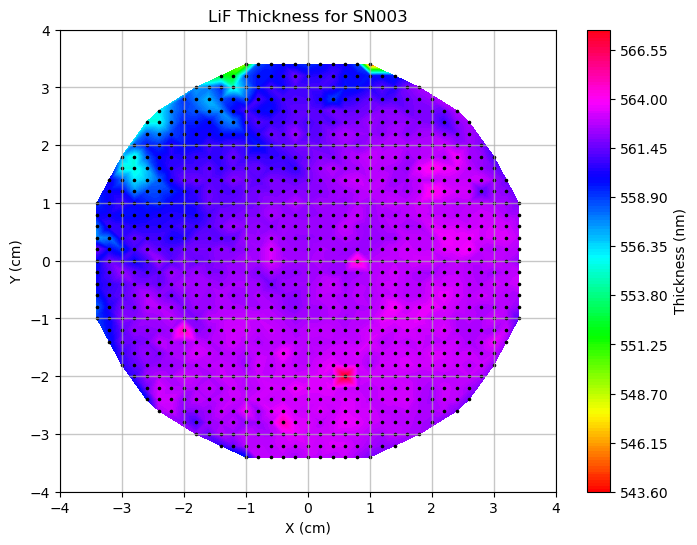

In [123]:
from DepositData import DepositData

SN003 = DepositData.from_file('Run11_25_SN003.txt', data_name='SN003')
SN003.Ron_plot()

This time the slope is oriented at roughly 135° to the original x-axis. Let's use that to fit this.

In [124]:
p03 = [SN003.zdata[494], 3 * np.pi/4, 1.0]
ff = lambda x, y: DepositData.fit_helper(x, y, 'angled_plane')
res3 = SN003.fit_to(ff, p03)
print(res)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 773.4474554100075
        x: [ 5.610e+02  2.665e-03  4.557e-01]
      nit: 14
      jac: [ 0.000e+00  7.629e-06  3.815e-05]
 hess_inv: [[ 3.468e-04 -2.694e-05  1.180e-04]
            [-2.694e-05  6.668e-05 -7.108e-05]
            [ 1.180e-04 -7.108e-05  2.047e-04]]
     nfev: 96
     njev: 24


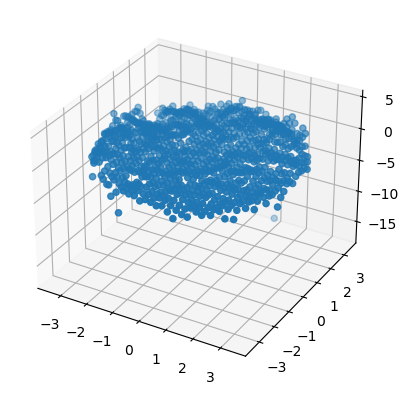

In [125]:
SN003.resid_plot3D()

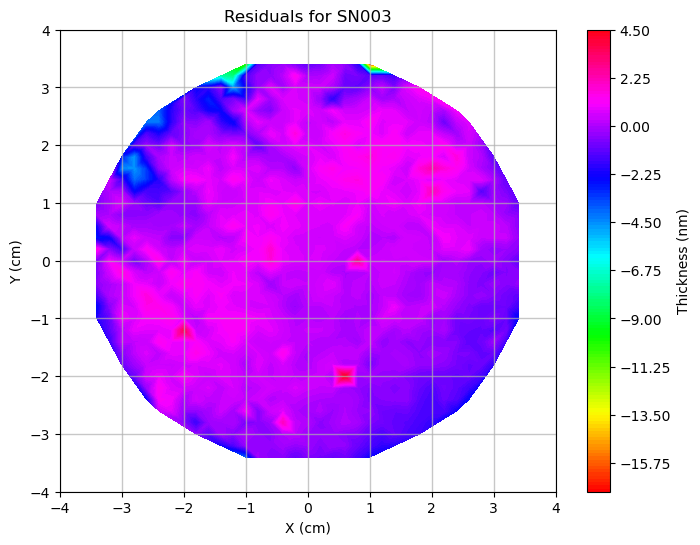

In [126]:
SN003.resid_plot()

Well, maybe this time we are seeing a wee bit of a quadratic term oriented in the same direciton as the slope. Apart from a few spots the range is down to less than 4 nm. Here are the histograms, again raw on the left and residuals on the right.

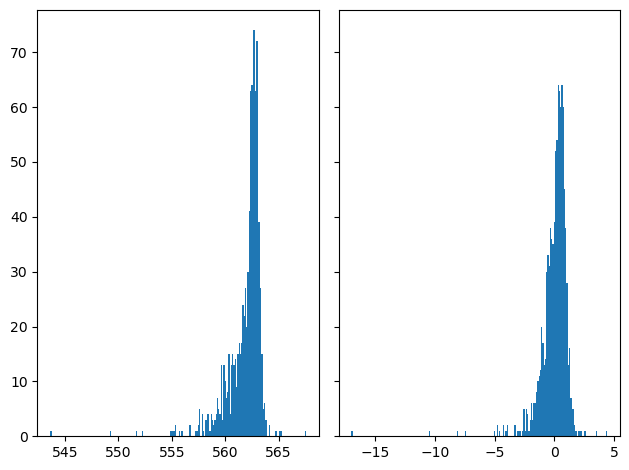

In [127]:
fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(SN003.zdata, bins=201)
axs[1].hist(SN003.resids, bins=201)

plt.show()

Again we see the narrowing brought about by the fitting though the outliers are wider spaced this time. We could prune outliers and refit I suppose. First though we should do deposit SN004.

### SN004

Same treatment.

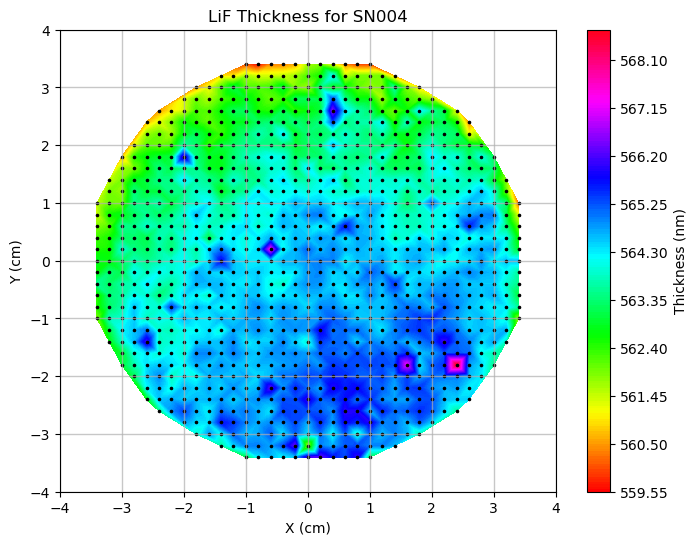

In [128]:
SN004 = DepositData.from_file('Run11_25_SN004.txt', data_name='SN004')
SN004.Ron_plot()

Fit using same guess.

In [129]:
res4 = SN004.fit_to(ff, p03)
print(res)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 773.4474554100075
        x: [ 5.610e+02  2.665e-03  4.557e-01]
      nit: 14
      jac: [ 0.000e+00  7.629e-06  3.815e-05]
 hess_inv: [[ 3.468e-04 -2.694e-05  1.180e-04]
            [-2.694e-05  6.668e-05 -7.108e-05]
            [ 1.180e-04 -7.108e-05  2.047e-04]]
     nfev: 96
     njev: 24


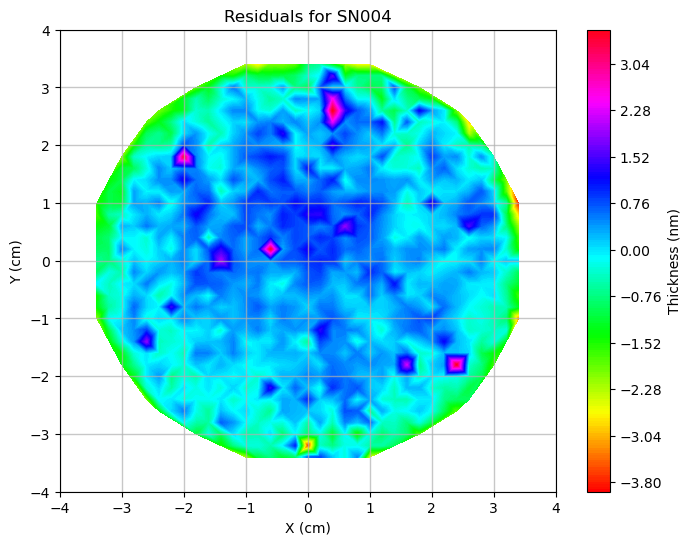

In [130]:
SN004.resid_plot()

This time we seem to have a low edge rim again. Let's look at the 3-D version.

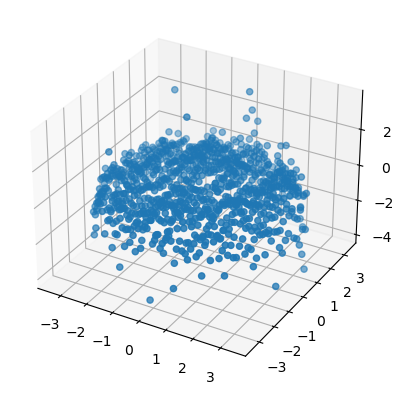

In [131]:
SN004.resid_plot3D()

Yes, the droopy edge is clearly visible. What about the histograms?

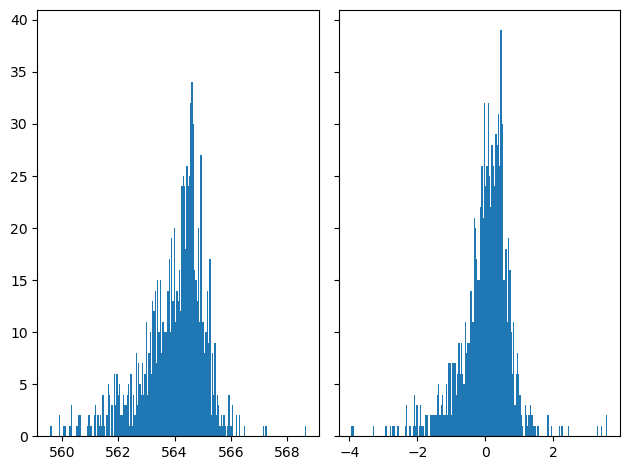

In [133]:
fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(SN004.zdata, bins=201)
axs[1].hist(SN004.resids, bins=201)

plt.show()

Extremely similar. So there is an intrinsic roughness at the $\pm2\,nm$ level plus a slope of similar magnitude and then odd spots that can be several nm away but have negligible area.

It is worth noting that the process is designed for making optical coatings and 2 nm is less than 1% of the wavelength of any light that will go through air!

Just for completeness and to make for easy reading let's redo the first deposit in exactly the same way.

### SN001

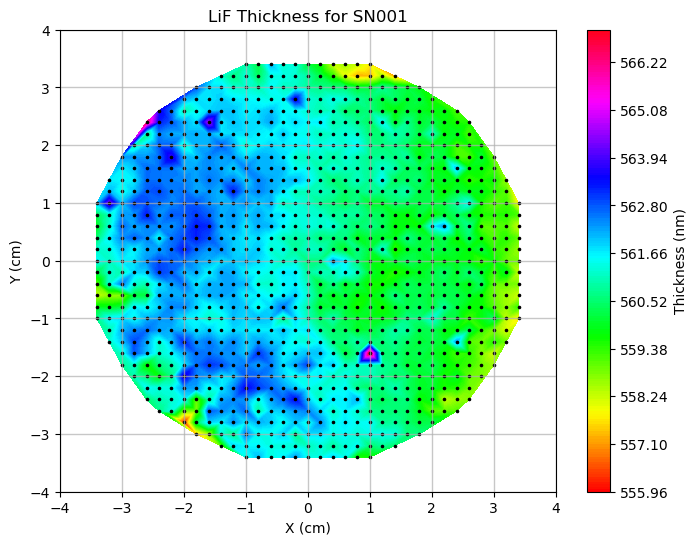

In [134]:
SN001 = DepositData.from_file('Run11_25_SN001.txt', data_name='SN001')
SN001.Ron_plot()

I'll use the similar starting parameters to those that worked earlier.

In [135]:
p01 = [SN001.zdata[494], 0.0, 1.0]
res4 = SN001.fit_to(ff, p01)
print(res)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 773.4474554100075
        x: [ 5.610e+02  2.665e-03  4.557e-01]
      nit: 14
      jac: [ 0.000e+00  7.629e-06  3.815e-05]
 hess_inv: [[ 3.468e-04 -2.694e-05  1.180e-04]
            [-2.694e-05  6.668e-05 -7.108e-05]
            [ 1.180e-04 -7.108e-05  2.047e-04]]
     nfev: 96
     njev: 24


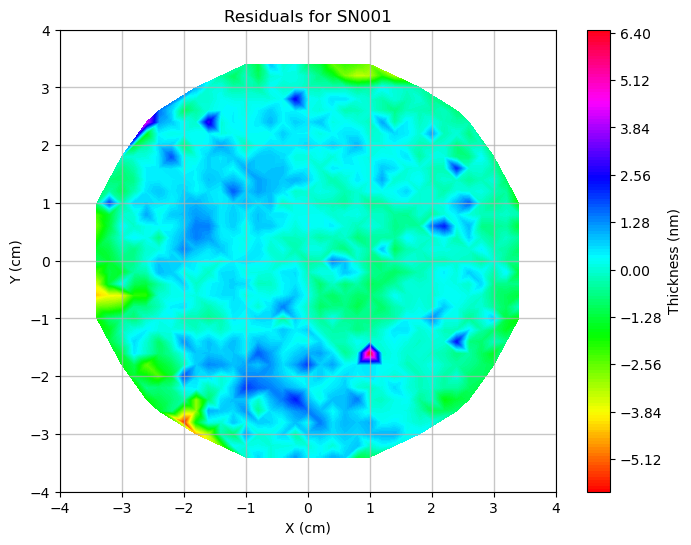

In [136]:
SN001.resid_plot()

Again, we the drooping edges though this time there appears to also be a slight dip in the middle giving a sort of donut shape. I don't think we will see in the 3D map.

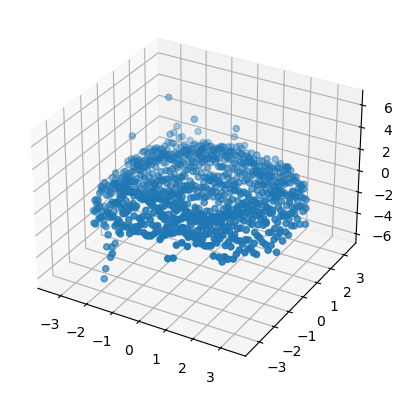

In [137]:
SN001.resid_plot3D()

Actually, there are hints that we are seeing the dip, though it is not clear and is down at or below the level of the general noise.

Here are the histograms.

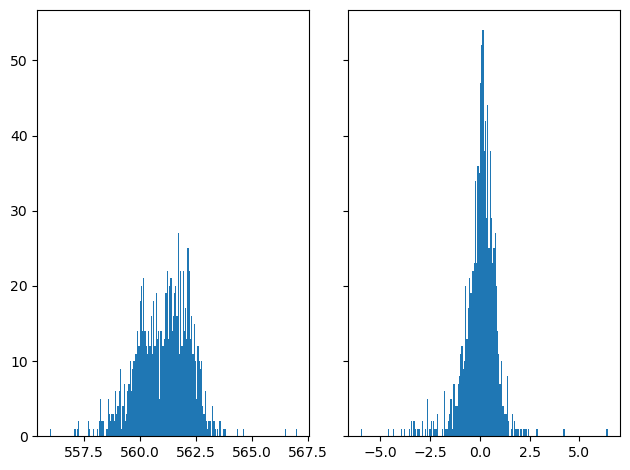

In [138]:
fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(SN001.zdata, bins=201)
axs[1].hist(SN001.resids, bins=201)

plt.show()

There is no sign of the dip showing up in the residual (right side) histogram but as before the fit has significantly sharpened the distribution.

Given the different orientations of the slopes it would be interesting to know how these are related to the orientations of the wafers and to their positions and orientations on the deposition platter.